# 1. Preparación de Datos y Filtro para América
En esta sección cargaremos los datos desde GitHub, arreglaremos los nombres de los países para unirlos correctamente y filtraremos solo los países de Norte, Sur, Centro América y el Caribe. Finalmente, proyectaremos el mapa a Equal Area (EPSG 8857).

In [23]:
!pip install thefuzz mapclassify geopandas

import geopandas as gpd
import pandas as pd
from thefuzz.process import extractOne
import matplotlib.pyplot as plt
import mapclassify

# 1. Cargar los archivos usando mis propios enlaces Raw de GitHub
link_world_maps = 'https://github.com/Romero-Luis21/TareaIndividual_Romero_Castillejo/raw/refs/heads/main/worldMaps.gpkg'
link_some_data = 'https://raw.githubusercontent.com/Romero-Luis21/TareaIndividual_Romero_Castillejo/refs/heads/main/some_dataworld.csv'

countries = gpd.read_file(link_world_maps, layer='countries')
someData = pd.read_csv(link_some_data)

# 2. Arreglar los nombres para hacer el Merge
countries.rename(columns={'COUNTRY':'Country'}, inplace=True)
countries['Country'] = countries.Country.str.upper()
someData['Country'] = someData.Country.str.upper()

onlyDF = set(someData.Country) - set(countries.Country)
onlyGDF = set(countries.Country) - set(someData.Country)

# Diccionario para "Fuzzy Merge" (arreglar países mal escritos)
changesToDF = {country: extractOne(country, onlyGDF)[0] for country in onlyDF}
someData.replace(to_replace={'Country':changesToDF}, inplace=True)

# 3. Unir los datos (Geo Merge)
theMapAndData = countries.merge(someData, on='Country')

# 4. FILTRAR POR AMÉRICA (Norte, Sur, Centro y Caribe)
regiones_america = ['NORTH AMERICA', 'SOUTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN']
america = theMapAndData[theMapAndData['region'].isin(regiones_america)].copy()

# 5. Proyectar a Equal Area (Requisito para mapas temáticos correctos, ej: EPSG 8857)
america_8857 = america.to_crs(8857)


# 2. Mapa Temático 1: DDM (Dot Density Map)
Mapa de densidad de puntos para la variable 'mobiles' (Usuarios de teléfonos móviles). Cada punto representará 1 millón de usuarios.

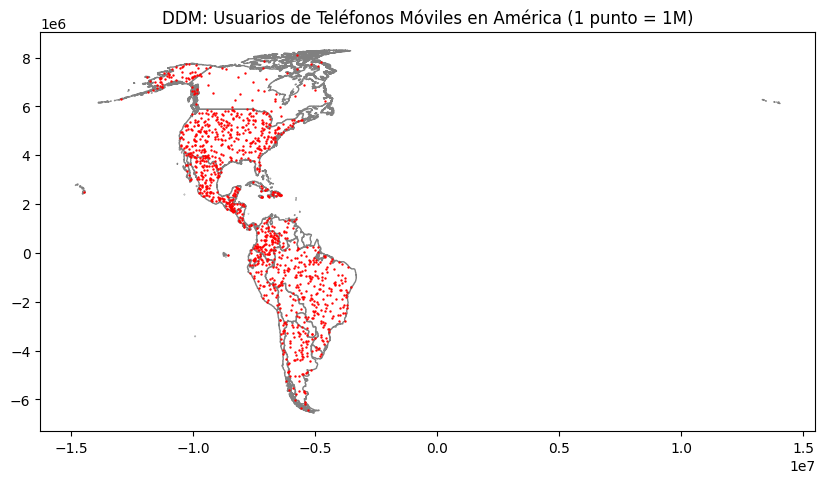

In [24]:
america_dots = america_8857.copy()

# 1 Punto = 1 Millón de celulares
dot_value = 1000000
america_dots['num_dots'] = (america_dots['mobiles'] / dot_value).astype(int)

# Distribuir los puntos
puntos = america_dots.sample_points(size=america_dots['num_dots']).explode(index_parts=True)
puntos.reset_index(drop=True, inplace=True)
america_dots_gdf = gpd.GeoDataFrame(geometry=puntos, crs=8857)

# Graficar
base = america_8857.plot(facecolor="white", edgecolor='grey', figsize=(10,10))
america_dots_gdf.plot(markersize=0.5, color='red', ax=base)
plt.title("DDM: Usuarios de Teléfonos Móviles en América (1 punto = 1M)")
plt.show()

# 3. Mapa Temático 2: PSM (Proportional Symbol Map)
Mapa de símbolos proporcionales. Detectaremos los valores atípicos (outliers) para destacarlos con un color diferente y escalaremos los círculos en función a la cantidad de celulares.

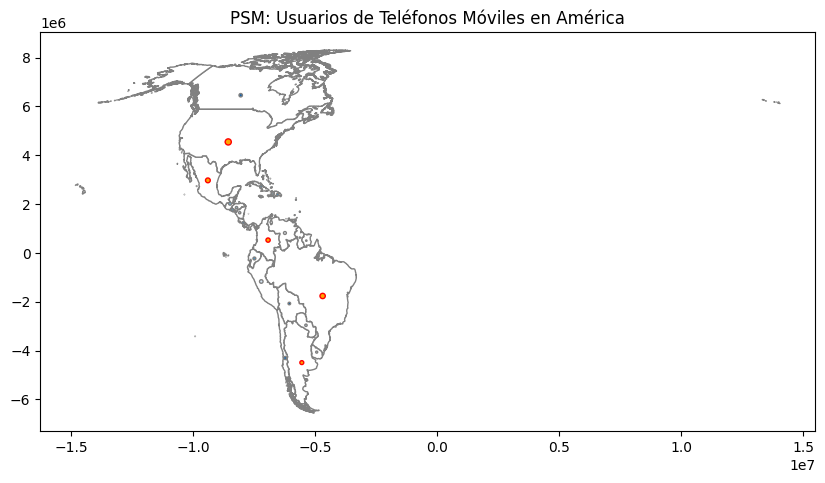

In [25]:
america_centroids = america_8857.copy()
america_centroids['geometry'] = america_centroids.representative_point()

# Separar outliers
boxplotInfo = america_centroids.boxplot(column='mobiles', return_type="dict")
outliers = boxplotInfo['fliers'][0].get_ydata()
plt.close() # Cierra el gráfico de caja

america_centroids['mobile_outlier'] = america_centroids.mobiles.isin(outliers) * 1
centroids_out = america_centroids[america_centroids.mobile_outlier == 1].copy()
centroids_no_out = america_centroids[america_centroids.mobile_outlier == 0].copy()

# Calcular el tamaño del símbolo
centroids_out['size'] = centroids_out['mobiles'].apply(lambda x: x**0.5 / 1000)
centroids_no_out['size'] = centroids_no_out['mobiles'].apply(lambda x: x**0.5 / 1000)

# Graficar
base = america_8857.plot(color='white', edgecolor='grey', figsize=(10,10))
centroids_no_out.plot(ax=base, markersize=centroids_no_out['size'], edgecolor='grey', c=centroids_no_out['size'], cmap='Blues_r')
centroids_out.plot(ax=base, markersize=centroids_out['size'], color='orange', edgecolor='red')
plt.title("PSM: Usuarios de Teléfonos Móviles en América")
plt.show()

# 4. Mapa Temático 3: Choropleth (Coropleta)
Para evitar errores metodológicos, normalizamos la variable dividiendo la cantidad de móviles entre la población total, obteniendo así los **Móviles per cápita**. Usaremos la clasificación Fisher-Jenks de 5 niveles.

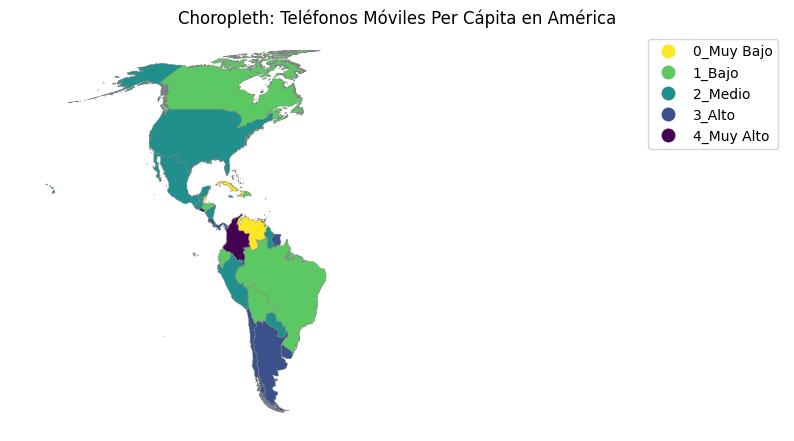

In [26]:
# NORMALIZADO
america_8857['mobiles_pc'] = america_8857['mobiles'] / america_8857['population']

# Clasificar usando el método Fisher-Jenks
fj5 = mapclassify.FisherJenks(america_8857['mobiles_pc'], k=5)
america_8857['mobiles_pc_FJ5'] = fj5.yb

etiquetas = {0:"0_Muy Bajo", 1:"1_Bajo", 2:"2_Medio", 3:"3_Alto", 4:"4_Muy Alto"}
america_8857['mobiles_pc_FJ5_cat'] = america_8857['mobiles_pc_FJ5'].replace(etiquetas)

# Graficar
f, ax = plt.subplots(1, figsize=(10, 10))
america_8857.plot(column='mobiles_pc_FJ5_cat',
                  cmap='viridis_r',
                  categorical=True,
                  edgecolor='grey',
                  linewidth=0.3,
                  legend=True,
                  ax=ax)
ax.set_axis_off()
plt.title("Choropleth: Teléfonos Móviles Per Cápita en América")
plt.show()

# 5. Exportar capas para el Dashboard en R (APLICADO A LA SIGUIENTE CLASE)
Exportamos todas las capas procesadas en un único archivo Geopackage (.gpkg).

In [27]:
# Guardar capas en un solo Geopackage
america_8857.to_file("america_mobiles.gpkg", driver='GPKG', layer='continent')
america_dots_gdf.to_file("america_mobiles.gpkg", driver='GPKG', layer='mobiles_ddm')
america_centroids.to_file("america_mobiles.gpkg", driver='GPKG', layer='mobiles_psm')
centroids_out.to_file("america_mobiles.gpkg", driver='GPKG', layer='outlier_mobiles_psm')
centroids_no_out.to_file("america_mobiles.gpkg", driver='GPKG', layer='no_outlier_mobiles_psm')